# **SVM Kernels Indepth Intutuion And Practical Explanaion**

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

1. np.linspace(start, stop, num) generates 100 evenly spaced values between -5 and 5. This provides smooth x-coordinates for plotting.
2. y = np.sqrt(10**2 - x**2)

This computes the positive y-values using the equation of a circle:

x
2
+y
2
=r
2

Rearranging for y:

y=
r
2
−x
2
	​


Here,

Radius r=10
Therefore,
y=
100−x
2
	​


This gives the upper semicircle.

3. -y creates the mirror image of the upper semicircle below the x-axis.
np.hstack() concatenates the two arrays horizontally into one larger array.

4. you obtain a circle-like shape centered at the origin with a radius of 10 units.


In [29]:
x

array([-5.        , -4.8989899 , -4.7979798 , -4.6969697 , -4.5959596 ,
       -4.49494949, -4.39393939, -4.29292929, -4.19191919, -4.09090909,
       -3.98989899, -3.88888889, -3.78787879, -3.68686869, -3.58585859,
       -3.48484848, -3.38383838, -3.28282828, -3.18181818, -3.08080808,
       -2.97979798, -2.87878788, -2.77777778, -2.67676768, -2.57575758,
       -2.47474747, -2.37373737, -2.27272727, -2.17171717, -2.07070707,
       -1.96969697, -1.86868687, -1.76767677, -1.66666667, -1.56565657,
       -1.46464646, -1.36363636, -1.26262626, -1.16161616, -1.06060606,
       -0.95959596, -0.85858586, -0.75757576, -0.65656566, -0.55555556,
       -0.45454545, -0.35353535, -0.25252525, -0.15151515, -0.05050505,
        0.05050505,  0.15151515,  0.25252525,  0.35353535,  0.45454545,
        0.55555556,  0.65656566,  0.75757576,  0.85858586,  0.95959596,
        1.06060606,  1.16161616,  1.26262626,  1.36363636,  1.46464646,
        1.56565657,  1.66666667,  1.76767677,  1.86868687,  1.96

In [30]:
y

array([ 8.66025404,  8.71779204,  8.77378994,  8.82827705,  8.88128118,
        8.93282873,  8.98294476,  9.03165312,  9.07897646,  9.12493632,
        9.16955321,  9.21284664,  9.25483518,  9.29553652,  9.3349675 ,
        9.37314414,  9.41008171,  9.44579475,  9.4802971 ,  9.51360192,
        9.54572176,  9.57666854,  9.60645359,  9.63508769,  9.66258107,
        9.68894344,  9.714184  ,  9.73831149,  9.76133416,  9.7832598 ,
        9.80409577,  9.82384901,  9.84252604,  9.86013297,  9.87667553,
        9.89215905,  9.90658851,  9.91996849,  9.93230325,  9.94359667,
        9.9538523 ,  9.96307334,  9.97126266,  9.9784228 ,  9.98455598,
        9.98966408,  9.99374868,  9.99681104,  9.99885209,  9.99987246,
        9.99987246,  9.99885209,  9.99681104,  9.99374868,  9.98966408,
        9.98455598,  9.9784228 ,  9.97126266,  9.96307334,  9.9538523 ,
        9.94359667,  9.93230325,  9.91996849,  9.90658851,  9.89215905,
        9.87667553,  9.86013297,  9.84252604,  9.82384901,  9.80

In [31]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

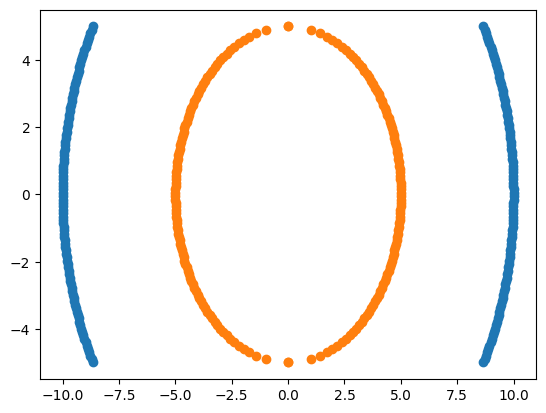

In [32]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [33]:
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


##### np.vstack() stands for Vertical Stack.

It is used to combine two or more arrays vertically (row-wise), meaning one array is placed below another. All arrays must have the same number of columns (or, for 1-D arrays, the same length)

Independent Features (Input Features)

These are the columns used to make predictions.

X1
X2

Dependent Feature (Target Variable)

This is the column the model tries to predict.

Y

In [34]:
df.tail()

,X1,X2,Y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


In [35]:
X=df.iloc[:,:2]
y=df.Y

In [36]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

## Train Test Split

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.25,random_state=0)

In [38]:
y_train

250    1
63     0
312    1
159    0
283    1
      ..
323    1
192    0
117    0
47     0
172    0
Name: Y, Length: 300, dtype: int64

## Polynomial Kernels

# K(x,y)=(x^T y+c)^d
is the Polynomial Kernel used in Support Vector Machines (SVMs). It measures the similarity between two data points while implicitly mapping them into a higher-dimensional polynomial feature space, allowing SVMs to learn non-linear decision boundaries

1. we need to find components for the Polynomial Kernel 
2. X1,X2,X1_square, X2_Square and X1*X2

In [39]:
df['X1_Square']=df['X1']**2
df['X2_Square']=df['X2']**2
df['X1*X2']=(df['X1']*df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [40]:
## Updated my Independent and dependent Feature
X=df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y= df['Y']

In [41]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.25,random_state=0)

In [43]:
X_train

,X1,X2,X1_Square,X2_Square,X1*X2
250,4.999745,0.050505,24.997449,0.002551,0.252512
63,9.906589,1.363636,98.140496,1.859504,13.508984
312,-3.263736,3.787879,10.651974,14.348026,-12.362637
159,-9.953852,-0.959596,99.079176,0.920824,9.551676
283,3.680983,3.383838,13.549638,11.450362,12.455852
...,...,...,...,...,...
323,-4.223140,2.676768,17.834915,7.165085,-11.304366
192,-9.031653,-4.292929,81.570758,18.429242,38.772248
117,-9.445795,3.282828,89.223038,10.776962,-31.008922
47,9.996811,-0.252525,99.936231,0.063769,-2.524447


In [44]:
import plotly.express as px
fig= px.scatter_3d(df, x='X1',y='X2', z='X1*X2', color='Y')
fig.show()

The above code uses Plotly Express to create an interactive 3D scatter plot. The x-axis represents X1, the y-axis represents X2, and the z-axis represents the interaction feature X1 × X2. Points are colored according to the class label Y. This visualization helps us understand how adding a polynomial feature maps the data into a higher-dimensional space, where classes that are not linearly separable in 2D may become separable by a plane in 3D.

In [48]:
fig= px.scatter_3d(df, x='X1_Square',y='X2_Square', z='X1*X2', color='Y')
fig.show()

The polynomial transformation creates new features such as:

X1^2
	​

X2^2
	​

X1

​
X2
	​


These map the original 2D data into a higher-dimensional feature space, where data that was not linearly separable may become linearly separable. This is the idea behind the polynomial kernel in SVM, although the kernel trick computes this transformation implicitly rather than creating the features explicitly.

In [54]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='linear')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

here we find manually x1, x2 both square as well as there product to find accuracy instead we have another option that we are used below

In [55]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='poly')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

when we use kernel='poly' in SVM, we do not create these features ourselves. The polynomial kernel uses the kernel trick to compute the same higher-dimensional representation implicitly. This makes the computation more efficient because the extra polynomial features are never explicitly generated, yet the SVM can still learn a non-linear decision boundary.

## uses **RBF** kenel
In contrast, the RBF kernel does not generate polynomial features. Instead, it computes the similarity between data points using the Gaussian function **K(x,y)=exp(−γ∥x−y∥
2
)**. This implicitly maps the data into an infinite-dimensional feature space, enabling SVM to learn very complex non-linear decision boundaries without explicitly creating new features.

In [56]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='rbf')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

## Uses **sigmoid** kernel
If you use the Sigmoid kernel instead of the Polynomial kernel, the SVM does not create polynomial features like **X1^2, X2^2, or X1X2**.

Instead, it computes the similarity between two data points using the hyperbolic tangent (tanh) function.

Sigmoid Kernel Formula
**K(x,y)=tanh(γx^Ty+r)**

where:

1. x and y are input vectors.
2. x^Ty is the dot product.
3. γ controls the slope.
4. r (coef0 in scikit-learn) is the bias/intercept

In [57]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='sigmoid')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0